# Module B — LightGBM Price Forecasting Model
**Project**: TOP (Tomato, Onion, Potato) Digital Twin  
**Target Journal**: Computers and Electronics in Agriculture / Agricultural Systems  
**Author**: Dr. Masroor, SKUAST-K (HADP-04)  

## Pipeline
1. Load master weekly panel (all 6 data sources merged)
2. Feature engineering (lags, rolling stats, seasonality dummies)
3. Train / validation / test split (temporal)
4. LightGBM training with Optuna hyperparameter tuning
5. Evaluation: RMSE, MAE, MAPE, R²
6. Feature importance + SHAP values
7. Export results for paper tables and figures

---
## 0. Imports and Config

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Paths ────────────────────────────────────────────────────────────
BASE     = r'C:\Users\masro\Documents\TOP_Digital_Twin'
AGM_DIR  = os.path.join(BASE, 'data', 'agmarknet_weekly')
CMIE_DIR = os.path.join(BASE, 'data', 'cmie_macro')
RBI_DIR  = os.path.join(BASE, 'data', 'rbi_dbie')
PPAC_DIR = os.path.join(BASE, 'data', 'ppac_macro')
SAT_DIR  = os.path.join(BASE, 'data', 'satellite_s2')
ERA5_DIR = os.path.join(BASE, 'data', 'era5_weather')
OUT_DIR  = os.path.join(BASE, 'Model_Output')
os.makedirs(OUT_DIR, exist_ok=True)

CROPS = ['tomato', 'onion', 'potato']

# Study window
TRAIN_END = '2022-12-31'
VAL_END   = '2023-12-31'
# Test = 2024 (held out)

print('Paths OK')
print(f'Output directory: {OUT_DIR}')
for name, path in [('Agmarknet', AGM_DIR), ('CMIE', CMIE_DIR),
                   ('RBI', RBI_DIR), ('PPAC', PPAC_DIR)]:
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  {name:<12}: {path}  [{status}]')

Paths OK
Output directory: C:\Users\masro\Documents\TOP_Digital_Twin\Model_Output
  Agmarknet   : C:\Users\masro\Documents\TOP_Digital_Twin\data\agmarknet_weekly  [OK]
  CMIE        : C:\Users\masro\Documents\TOP_Digital_Twin\data\cmie_macro  [OK]
  RBI         : C:\Users\masro\Documents\TOP_Digital_Twin\data\rbi_dbie  [OK]
  PPAC        : C:\Users\masro\Documents\TOP_Digital_Twin\data\ppac_macro  [OK]


---
## 1. Load Data Sources

In [2]:
# ── 1a. Agmarknet Weekly Panel ────────────────────────────────────────
agm = pd.read_csv(os.path.join(AGM_DIR, 'top_weekly_panel.csv'), parse_dates=['week_start'])
print(f'Agmarknet: {len(agm):,} rows  |  crops: {agm["crop"].unique()}')
agm.head(3)

Agmarknet: 456,907 rows  |  crops: <StringArray>
['tomato', 'onion', 'potato']
Length: 3, dtype: str


,crop,state,state_code,district,market,market_id,week_start,iso_year,iso_week,modal_price_weighted,arrivals_tonnes_week,trading_days
0,tomato,Telangana,TL,Hyderabad,Mahboob Manison APMC,2.000,2022-08-01,2022,31,1000.000,250.000,1.000
1,tomato,Telangana,TL,Hyderabad,Mahboob Manison APMC,2.000,2022-08-15,2022,33,853.372,1023.000,5.000
2,tomato,Telangana,TL,Hyderabad,Mahboob Manison APMC,2.000,2022-08-22,2022,34,972.675,1226.000,6.000


In [3]:
# ── 1b. CMIE Macro (monthly → will be joined on year-month) ──────────
cmie = pd.read_csv(os.path.join(CMIE_DIR, 'cmie_macro_2017_2024.csv'), parse_dates=['date'])
print(f'CMIE macro: {len(cmie)} rows  |  cols: {list(cmie.columns)}')
cmie.head(3)

CMIE macro: 96 rows  |  cols: ['date', 'year', 'month', 'bank_credit_agri_cr', 'export_veg_usd_mn', 'import_veg_usd_mn', 'crude_oil_usd_bbl', 'iip_food_proc', 'agri_wages_rs_day']


,date,year,month,bank_credit_agri_cr,export_veg_usd_mn,import_veg_usd_mn,crude_oil_usd_bbl,iip_food_proc,agri_wages_rs_day
0,2017-01-01,2017,1,9171460.000,2814.600,2282.300,54.080,123.100,301.900
1,2017-02-01,2017,2,9301510.000,3045.200,2332.600,54.860,119.700,302.200
2,2017-03-01,2017,3,9909210.000,3520.300,2476.900,51.470,132.700,302.400


In [4]:
# ── 1c. RBI DBIE Macro ───────────────────────────────────────────────
rbi = pd.read_csv(os.path.join(RBI_DIR, 'rbi_dbie_macro_2017_2024.csv'), parse_dates=['date'])
print(f'RBI DBIE: {len(rbi)} rows  |  cols: {list(rbi.columns)}')
rbi.head(3)

RBI DBIE: 96 rows  |  cols: ['date', 'year', 'month', 'repo_rate_pct', 'reverse_repo_pct', 'usdinr_monthly_avg', 'wpi_all_commodities', 'wpi_food_articles', 'wpi_fruits_vegetables']


,date,year,month,repo_rate_pct,reverse_repo_pct,usdinr_monthly_avg,wpi_all_commodities,wpi_food_articles,wpi_fruits_vegetables
0,2017-01-01,2017,1,6.250,5.750,68.080,112.600,136.500,117.500
1,2017-02-01,2017,2,6.250,5.750,67.075,113.000,136.600,120.600
2,2017-03-01,2017,3,6.250,5.750,65.929,113.200,137.600,128.000


In [5]:
# ── 1d. PPAC Fuel Prices ─────────────────────────────────────────────
ppac = pd.read_csv(os.path.join(PPAC_DIR, 'ppac_diesel_lpg_2017_2024.csv'), parse_dates=['date'])
print(f'PPAC: {len(ppac)} rows  |  cols: {list(ppac.columns)}')
ppac.head(3)

PPAC: 96 rows  |  cols: ['date', 'year', 'month', 'diesel_delhi_per_L', 'lpg_nonsub_delhi_per14kg']


,date,year,month,diesel_delhi_per_L,lpg_nonsub_delhi_per14kg
0,2017-01-01,2017,1,58.400,585.000
1,2017-02-01,2017,2,59.000,651.500
2,2017-03-01,2017,3,59.000,737.500


In [6]:
# ── 1e. Satellite S2 (if available) ──────────────────────────────────
sat_file = os.path.join(SAT_DIR, 's2_weekly_vi.csv')   # adjust filename as needed
if os.path.exists(sat_file):
    sat = pd.read_csv(sat_file, parse_dates=['week_start'])
    print(f'Satellite S2: {len(sat):,} rows  |  cols: {list(sat.columns)}')
else:
    sat = None
    print('Satellite S2 file not found — will run without satellite features.')

Satellite S2 file not found — will run without satellite features.


In [7]:
# ── 1f. ERA5 Weather (if available) ──────────────────────────────────
era5_file = os.path.join(ERA5_DIR, 'era5_weekly.csv')   # adjust filename as needed
if os.path.exists(era5_file):
    era5 = pd.read_csv(era5_file, parse_dates=['week_start'])
    print(f'ERA5: {len(era5):,} rows  |  cols: {list(era5.columns)}')
else:
    era5 = None
    print('ERA5 file not found — will run without weather features.')

ERA5 file not found — will run without weather features.


---
## 2. Build Monthly Macro Table
CMIE, RBI and PPAC are monthly. Merge them into one macro table, then join to weekly panel on year-month.

In [8]:
macro = (
    cmie
    .merge(rbi,  on='date', how='outer', suffixes=('', '_rbi'))
    .merge(ppac, on='date', how='outer', suffixes=('', '_ppac'))
    .sort_values('date')
    .reset_index(drop=True)
)
# Drop duplicate year/month cols that came from rbi/ppac
macro = macro[[c for c in macro.columns if not c.endswith(('_rbi', '_ppac'))]]
macro['ym'] = macro['date'].dt.to_period('M')

print(f'Macro table: {len(macro)} rows  |  {len(macro.columns)} cols')
print(macro.isnull().sum().to_string())
macro.tail(3)

Macro table: 96 rows  |  18 cols
date                        0
year                        0
month                       0
bank_credit_agri_cr         0
export_veg_usd_mn           0
import_veg_usd_mn           0
crude_oil_usd_bbl           0
iip_food_proc               0
agri_wages_rs_day           1
repo_rate_pct               0
reverse_repo_pct            0
usdinr_monthly_avg          0
wpi_all_commodities         0
wpi_food_articles           0
wpi_fruits_vegetables       0
diesel_delhi_per_L          0
lpg_nonsub_delhi_per14kg    0
ym                          0


,date,year,month,bank_credit_agri_cr,export_veg_usd_mn,import_veg_usd_mn,crude_oil_usd_bbl,iip_food_proc,agri_wages_rs_day,repo_rate_pct,reverse_repo_pct,usdinr_monthly_avg,wpi_all_commodities,wpi_food_articles,wpi_fruits_vegetables,diesel_delhi_per_L,lpg_nonsub_delhi_per14kg,ym
93,2024-10-01,2024,10,22007159.000,4475.700,3620.400,75.120,148.400,436.300,6.500,3.350,84.029,156.700,217.900,291.600,87.700,803.000,2024-10
94,2024-11-01,2024,11,22103116.800,4218.500,3754.400,73.020,147.000,438.500,6.500,3.350,84.364,156.400,213.700,271.900,87.700,803.000,2024-11
95,2024-12-01,2024,12,22366483.400,4863.700,3412.200,73.340,157.200,440.100,6.500,3.350,84.986,155.700,207.500,244.700,87.700,803.000,2024-12


---
## 3. Feature Engineering

In [9]:
def build_features(crop_name: str, panel: pd.DataFrame, macro: pd.DataFrame,
                   sat=None, era5=None) -> pd.DataFrame:
    """
    Build feature matrix for one crop.
    Returns a DataFrame with target = modal_price_weighted (t+1 week ahead).
    """
    df = panel[panel['crop'] == crop_name].copy()
    df = df.sort_values(['market_id', 'week_start']).reset_index(drop=True)

    # ── Calendar features ────────────────────────────────────────────
    df['month']      = df['week_start'].dt.month
    df['week_of_yr'] = df['week_start'].dt.isocalendar().week.astype(int)
    df['sin_week']   = np.sin(2 * np.pi * df['week_of_yr'] / 52)
    df['cos_week']   = np.cos(2 * np.pi * df['week_of_yr'] / 52)
    df['sin_month']  = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month']  = np.cos(2 * np.pi * df['month'] / 12)

    # ── Price lags (per market) ───────────────────────────────────────
    for lag in [1, 2, 3, 4, 8, 13, 26, 52]:
        df[f'price_lag_{lag}'] = (
            df.groupby('market_id')['modal_price_weighted']
              .shift(lag)
        )

    # ── Rolling stats ─────────────────────────────────────────────────
    g = df.groupby('market_id')['modal_price_weighted']
    for w in [4, 8, 13]:
        df[f'price_roll_mean_{w}'] = g.transform(lambda x: x.shift(1).rolling(w).mean())
        df[f'price_roll_std_{w}']  = g.transform(lambda x: x.shift(1).rolling(w).std())

    # ── Arrivals features ─────────────────────────────────────────────
    df['arr_lag_1']       = df.groupby('market_id')['arrivals_tonnes_week'].shift(1)
    df['arr_roll_mean_4'] = (
        df.groupby('market_id')['arrivals_tonnes_week']
          .transform(lambda x: x.shift(1).rolling(4).mean())
    )

    # ── Year-over-year price change ───────────────────────────────────
    df['price_yoy'] = (
        df.groupby(['market_id', 'week_of_yr'])['modal_price_weighted']
          .shift(1)  # same week last year (approx)
    )
    df['price_yoy_pct'] = (df['modal_price_weighted'] - df['price_yoy']) / df['price_yoy']

    # ── Join monthly macro on year-month ──────────────────────────────
    df['ym'] = df['week_start'].dt.to_period('M')
    macro_cols = [c for c in macro.columns if c != 'date' and c not in ['year','month']]
    df = df.merge(macro[macro_cols], on='ym', how='left')

    # ── Satellite VI (optional) ───────────────────────────────────────
    if sat is not None:
        sat_crop = sat[sat['crop'] == crop_name] if 'crop' in sat.columns else sat
        df = df.merge(sat_crop.drop(columns=['crop'], errors='ignore'),
                      on='week_start', how='left')

    # ── ERA5 weather (optional) ───────────────────────────────────────
    if era5 is not None:
        era5_crop = era5[era5['crop'] == crop_name] if 'crop' in era5.columns else era5
        df = df.merge(era5_crop.drop(columns=['crop'], errors='ignore'),
                      on='week_start', how='left')

    # ── Target: next-week price ───────────────────────────────────────
    df['target'] = df.groupby('market_id')['modal_price_weighted'].shift(-1)

    # Drop rows with NaN target
    df = df.dropna(subset=['target'])

    return df


print('Feature builder defined.')

Feature builder defined.


In [10]:
# Build for each crop
feat = {}
for crop in CROPS:
    feat[crop] = build_features(crop, agm, macro, sat=sat, era5=era5)
    print(f'{crop}: {feat[crop].shape}  |  NaN in target: {feat[crop]["target"].isna().sum()}')

feat['tomato'].head(2)

tomato: (279023, 52)  |  NaN in target: 0
onion: (142663, 52)  |  NaN in target: 0
potato: (32714, 52)  |  NaN in target: 0


,crop,state,state_code,district,market,market_id,week_start,iso_year,iso_week,modal_price_weighted,arrivals_tonnes_week,trading_days,month,week_of_yr,sin_week,cos_week,sin_month,cos_month,price_lag_1,price_lag_2,price_lag_3,price_lag_4,price_lag_8,price_lag_13,price_lag_26,...,price_roll_std_4,price_roll_mean_8,price_roll_std_8,price_roll_mean_13,price_roll_std_13,arr_lag_1,arr_roll_mean_4,price_yoy,price_yoy_pct,ym,bank_credit_agri_cr,export_veg_usd_mn,import_veg_usd_mn,crude_oil_usd_bbl,iip_food_proc,agri_wages_rs_day,repo_rate_pct,reverse_repo_pct,usdinr_monthly_avg,wpi_all_commodities,wpi_food_articles,wpi_fruits_vegetables,diesel_delhi_per_L,lpg_nonsub_delhi_per14kg,target
0,tomato,Telangana,TL,Hyderabad,Mahboob Manison APMC,2.000,2022-08-01,2022,31,1000.000,250.000,1.000,8,31,-0.568,-0.823,-0.866,-0.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-08,15756970.000,4131.000,3469.600,97.400,131.300,383.000,5.400,3.350,79.555,153.200,182.000,216.400,89.700,1053.000,853.372
1,tomato,Telangana,TL,Hyderabad,Mahboob Manison APMC,2.000,2022-08-15,2022,33,853.372,1023.000,5.000,8,33,-0.749,-0.663,-0.866,-0.500,1000.000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,250.000,NaN,NaN,NaN,2022-08,15756970.000,4131.000,3469.600,97.400,131.300,383.000,5.400,3.350,79.555,153.200,182.000,216.400,89.700,1053.000,972.675


---
## 4. Train / Validation / Test Split
- **Train**: 2017–2022
- **Val**:   2023
- **Test**:  2024 (held out, never used for tuning)

In [12]:
EXCLUDE_COLS = [
    'crop', 'state', 'state_code', 'district', 'market',
    'week_start', 'ym', 'target',
    'modal_price_weighted',  # current-week price (leaks into target)
]

splits = {}  # crop → {X_train, y_train, X_val, y_val, X_test, y_test, feature_cols}

for crop in CROPS:
    df = feat[crop].copy()

    # Encode categorical columns BEFORE splitting so all subsets see them
    for cat_col in ['state_code', 'market_id']:
        if cat_col in df.columns:
            df[cat_col + '_enc'] = pd.Categorical(df[cat_col]).codes

    train = df[df['week_start'] <= TRAIN_END]
    val   = df[(df['week_start'] > TRAIN_END) & (df['week_start'] <= VAL_END)]
    test  = df[df['week_start'] > VAL_END]

    feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

    splits[crop] = {
        'X_train': train[feature_cols],
        'y_train': train['target'],
        'X_val':   val[feature_cols],
        'y_val':   val['target'],
        'X_test':  test[feature_cols],
        'y_test':  test['target'],
        'feature_cols': feature_cols,
        'test_df': test,
    }
    print(f'{crop:8s}  train={len(train):,}  val={len(val):,}  test={len(test):,}  features={len(feature_cols)}')

tomato    train=201,738  val=36,338  test=40,947  features=45
onion     train=103,868  val=20,123  test=18,672  features=45
potato    train=24,255  val=4,195  test=4,264  features=45


---
## 5. LightGBM Training (Baseline)

In [13]:
# Install if needed: pip install lightgbm optuna shap
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


BASE_PARAMS = {
    'objective':        'regression',
    'metric':           'rmse',
    'learning_rate':    0.05,
    'num_leaves':       63,
    'min_child_samples':20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'lambda_l1':        0.1,
    'lambda_l2':        0.1,
    'verbose':         -1,
    'n_jobs':          -1,
    'seed':             42,
}

models   = {}
metrics  = {}

for crop in CROPS:
    s = splits[crop]
    X_tr, y_tr = s['X_train'], s['y_train']
    X_va, y_va = s['X_val'],   s['y_val']
    X_te, y_te = s['X_test'],  s['y_test']

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_va, label=y_va, reference=dtrain)

    model = lgb.train(
        BASE_PARAMS,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=200),
        ]
    )
    models[crop] = model

    pred_te = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred_te))
    mae  = mean_absolute_error(y_te, pred_te)
    mpe  = mape(y_te.values, pred_te)
    r2   = r2_score(y_te, pred_te)

    metrics[crop] = {'RMSE': rmse, 'MAE': mae, 'MAPE%': mpe, 'R2': r2,
                     'best_iter': model.best_iteration}
    print(f'{crop:8s}  RMSE={rmse:.1f}  MAE={mae:.1f}  MAPE={mpe:.1f}%  R²={r2:.3f}')

[200]	valid_0's rmse: 1304.87
[400]	valid_0's rmse: 1295.42
tomato    RMSE=905.6  MAE=596.5  MAPE=36.2%  R²=0.667
[200]	valid_0's rmse: 578.809
[400]	valid_0's rmse: 570.407
onion     RMSE=592.6  MAE=433.0  MAPE=16.0%  R²=0.834
[200]	valid_0's rmse: 122.604
[400]	valid_0's rmse: 119.29
[600]	valid_0's rmse: 118.983
potato    RMSE=224.0  MAE=168.5  MAPE=8.9%  R²=0.884


In [14]:
# Summary table — paper Table 4
metrics_df = pd.DataFrame(metrics).T.round(3)
metrics_df.index.name = 'Crop'
print(metrics_df.to_string())
metrics_df.to_csv(os.path.join(OUT_DIR, 'table4_model_metrics.csv'))

          RMSE     MAE  MAPE%    R2  best_iter
Crop                                          
tomato 905.599 596.451 36.182 0.667    393.000
onion  592.601 432.962 16.010 0.834    407.000
potato 224.036 168.503  8.885 0.884    627.000


---
## 6. Hyperparameter Tuning (Optuna)
Run once — takes ~20-40 min per crop. Skip to Section 7 if baseline metrics are sufficient.

In [15]:
# Uncomment to run Optuna tuning

# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)
#
# def objective(trial, crop):
#     s = splits[crop]
#     params = {
#         'objective':        'regression',
#         'metric':           'rmse',
#         'verbose':         -1,
#         'n_jobs':          -1,
#         'seed':             42,
#         'learning_rate':    trial.suggest_float('lr', 0.01, 0.1, log=True),
#         'num_leaves':       trial.suggest_int('num_leaves', 31, 255),
#         'min_child_samples':trial.suggest_int('min_child_samples', 10, 100),
#         'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
#         'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
#         'bagging_freq':     trial.suggest_int('bagging_freq', 1, 10),
#         'lambda_l1':        trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True),
#         'lambda_l2':        trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
#     }
#     dtrain = lgb.Dataset(s['X_train'], label=s['y_train'])
#     dval   = lgb.Dataset(s['X_val'],   label=s['y_val'], reference=dtrain)
#     model  = lgb.train(params, dtrain, num_boost_round=2000,
#                        valid_sets=[dval],
#                        callbacks=[lgb.early_stopping(100, verbose=False),
#                                   lgb.log_evaluation(period=-1)])
#     pred = model.predict(s['X_val'])
#     return np.sqrt(mean_squared_error(s['y_val'], pred))
#
# best_models = {}
# for crop in CROPS:
#     study = optuna.create_study(direction='minimize',
#                                  sampler=optuna.samplers.TPESampler(seed=42))
#     study.optimize(lambda t: objective(t, crop), n_trials=100, show_progress_bar=True)
#     print(f'{crop}: best RMSE={study.best_value:.1f}  params={study.best_params}')

print('Optuna block ready — uncomment to run.')

Optuna block ready — uncomment to run.


---
## 7. Feature Importance

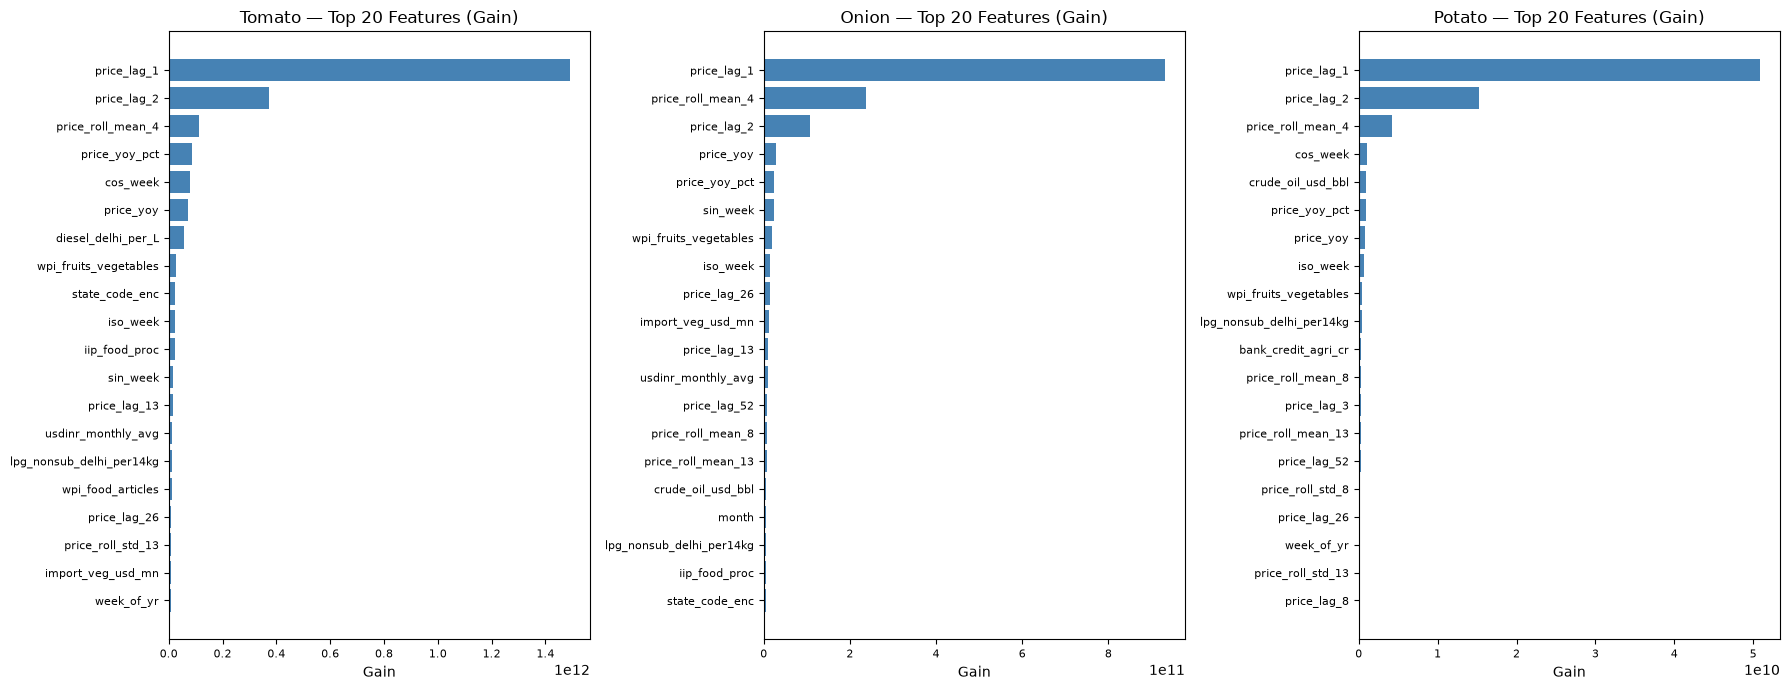

Saved: fig_feature_importance.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, crop in zip(axes, CROPS):
    model = models[crop]
    imp   = pd.Series(model.feature_importance(importance_type='gain'),
                      index=splits[crop]['feature_cols'])
    imp   = imp.sort_values(ascending=False).head(20)
    imp   = imp.sort_values()   # ascending for horizontal bar

    ax.barh(imp.index, imp.values, color='steelblue')
    ax.set_title(f'{crop.capitalize()} — Top 20 Features (Gain)', fontsize=12)
    ax.set_xlabel('Gain')
    ax.tick_params(labelsize=8)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_feature_importance.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fig_feature_importance.png')

---
## 8. SHAP Values

In [17]:
import shap

shap_values = {}

for crop in CROPS:
    s = splits[crop]
    explainer = shap.TreeExplainer(models[crop])
    # Use test set (subsample for speed)
    X_sample = s['X_test'].sample(min(2000, len(s['X_test'])), random_state=42)
    sv = explainer.shap_values(X_sample)
    shap_values[crop] = (sv, X_sample)
    print(f'{crop}: SHAP computed on {len(X_sample)} test samples')

tomato: SHAP computed on 2000 test samples
onion: SHAP computed on 2000 test samples
potato: SHAP computed on 2000 test samples


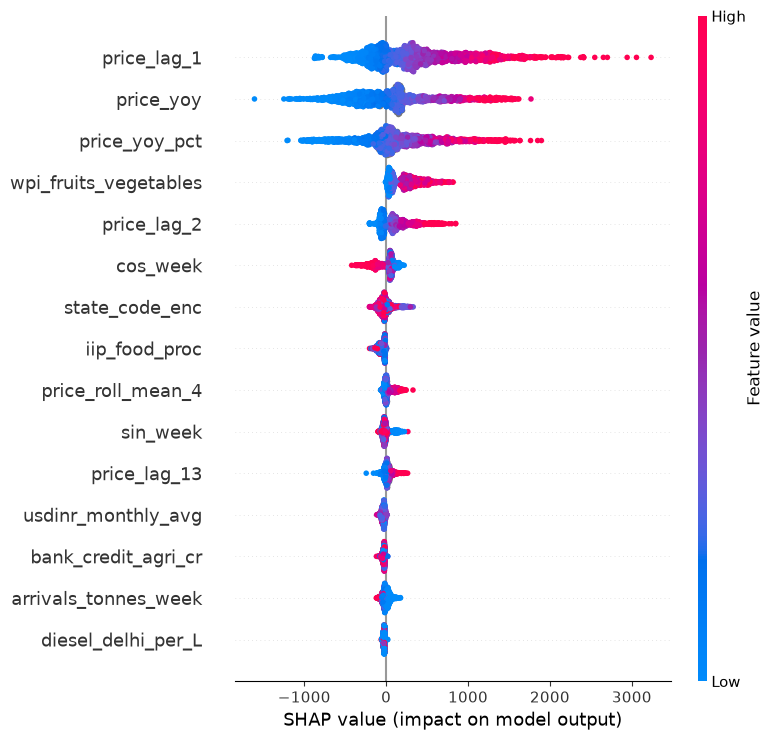

Saved: fig_shap_tomato.png


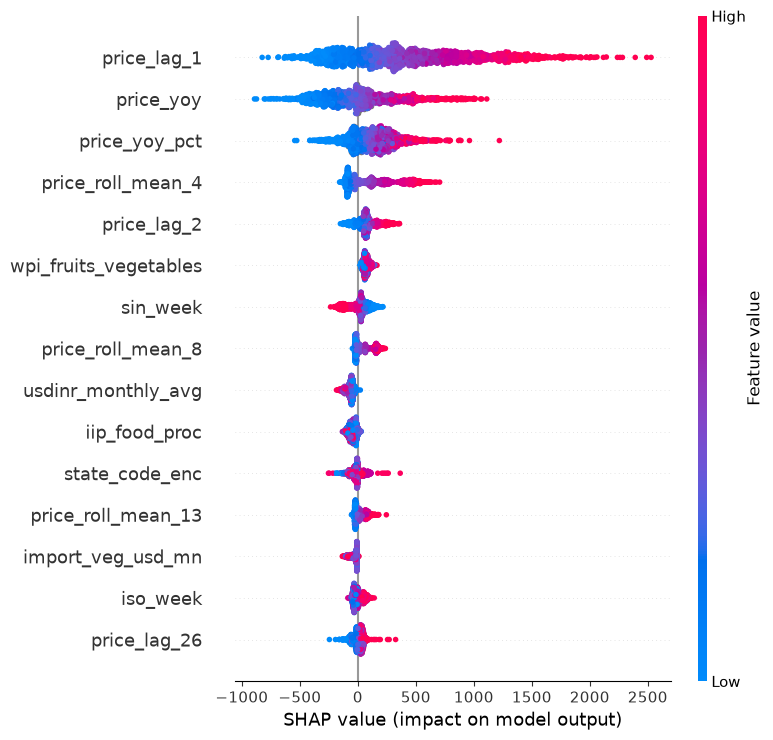

Saved: fig_shap_onion.png


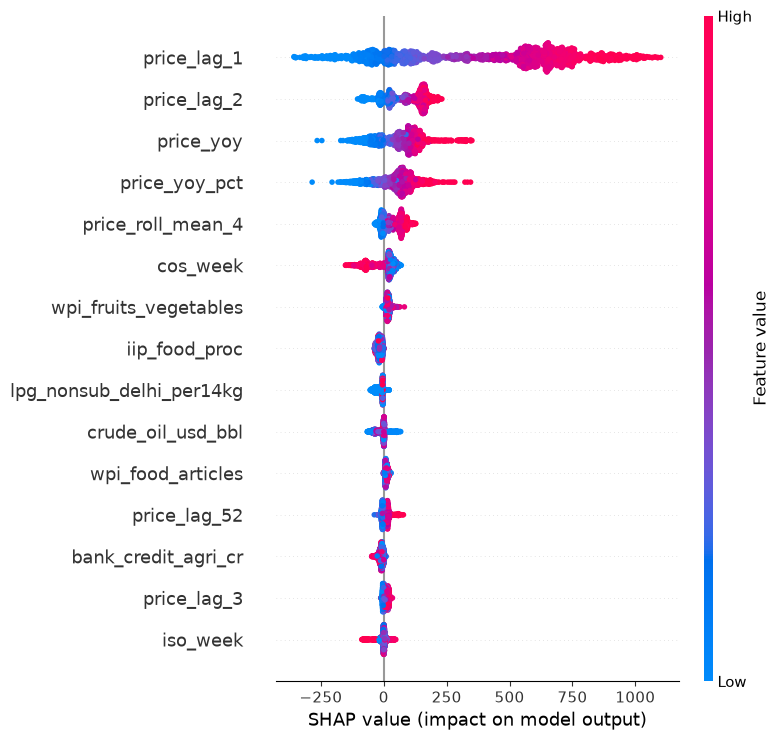

Saved: fig_shap_potato.png


In [18]:
# SHAP beeswarm plots — paper Figure 5
for crop in CROPS:
    sv, X_sample = shap_values[crop]
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_sample, max_display=15, show=False,
                      title=f'{crop.capitalize()} — SHAP Summary')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'fig_shap_{crop}.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: fig_shap_{crop}.png')

---
## 9. Actual vs Predicted Plot (Test Set 2024)

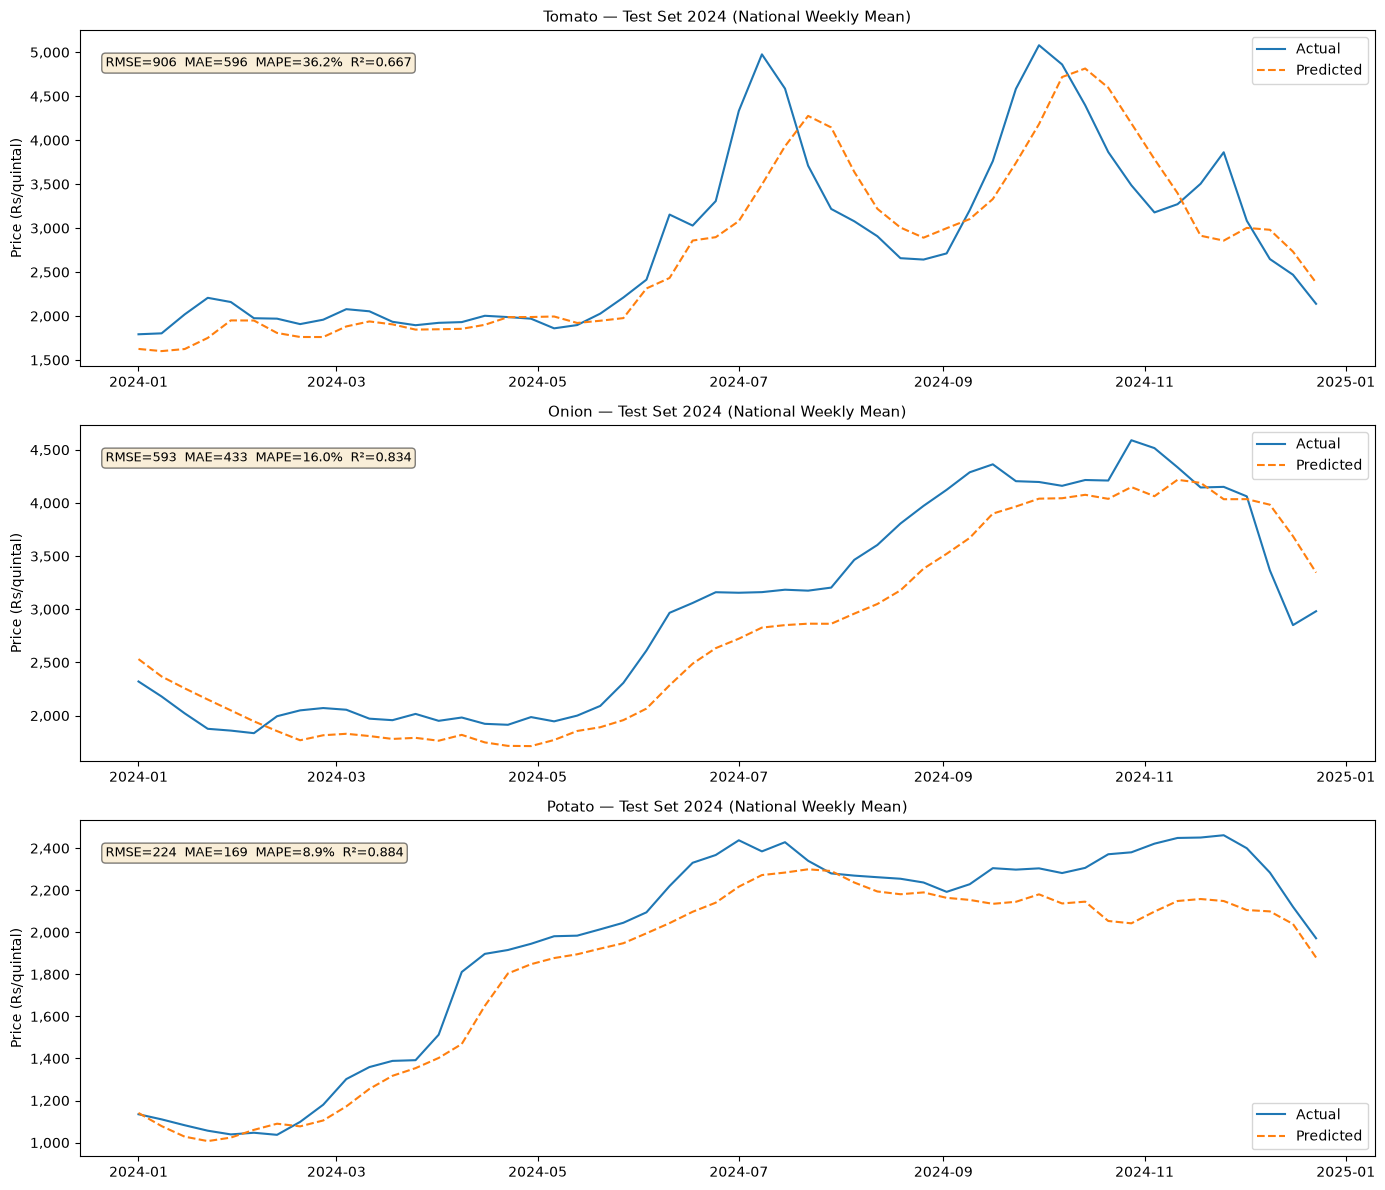

Saved: fig_actual_vs_pred_2024.png


In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, crop in zip(axes, CROPS):
    s  = splits[crop]
    te = s['test_df'].copy()
    te['pred'] = models[crop].predict(s['X_test'])

    # National weekly average
    grp = te.groupby('week_start').agg(
        actual=('target', 'mean'),
        predicted=('pred', 'mean')
    ).reset_index()

    ax.plot(grp['week_start'], grp['actual'],    label='Actual',    linewidth=1.5)
    ax.plot(grp['week_start'], grp['predicted'], label='Predicted', linewidth=1.5, linestyle='--')
    ax.set_title(f'{crop.capitalize()} — Test Set 2024 (National Weekly Mean)', fontsize=11)
    ax.set_ylabel('Price (Rs/quintal)')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    m = metrics[crop]
    ax.text(0.02, 0.92,
            f'RMSE={m["RMSE"]:.0f}  MAE={m["MAE"]:.0f}  MAPE={m["MAPE%"]:.1f}%  R²={m["R2"]:.3f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_actual_vs_pred_2024.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fig_actual_vs_pred_2024.png')

---
## 10. Save Final Predictions

In [20]:
all_preds = []

for crop in CROPS:
    s  = splits[crop]
    te = s['test_df'][['crop','state','market_id','market','week_start','target']].copy()
    te['predicted'] = models[crop].predict(s['X_test'])
    te['residual']  = te['target'] - te['predicted']
    all_preds.append(te)

preds_df = pd.concat(all_preds, ignore_index=True)
preds_df.to_csv(os.path.join(OUT_DIR, 'test_predictions_2024.csv'), index=False)
print(f'Saved: test_predictions_2024.csv  ({len(preds_df):,} rows)')
preds_df.head(5)

Saved: test_predictions_2024.csv  (63,883 rows)


,crop,state,market_id,market,week_start,target,predicted,residual
0,tomato,Telangana,2.000,Mahboob Manison APMC,2024-01-01,1149.904,1241.931,-92.027
1,tomato,Telangana,2.000,Mahboob Manison APMC,2024-01-08,1471.152,1081.860,389.292
2,tomato,Telangana,2.000,Mahboob Manison APMC,2024-01-15,1437.660,1363.509,74.151
3,tomato,Telangana,2.000,Mahboob Manison APMC,2024-01-22,1610.056,1293.067,316.989
4,tomato,Telangana,2.000,Mahboob Manison APMC,2024-01-29,1680.752,1444.331,236.420


In [21]:
# Save models
for crop in CROPS:
    mpath = os.path.join(OUT_DIR, f'lgbm_{crop}.txt')
    models[crop].save_model(mpath)
    print(f'Model saved: {mpath}')

print('\nAll outputs in:', OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    sz = os.path.getsize(os.path.join(OUT_DIR, f)) / 1024
    print(f'  {f:<45} {sz:>7.1f} KB')

Model saved: C:\Users\masro\Documents\TOP_Digital_Twin\Model_Output\lgbm_tomato.txt
Model saved: C:\Users\masro\Documents\TOP_Digital_Twin\Model_Output\lgbm_onion.txt
Model saved: C:\Users\masro\Documents\TOP_Digital_Twin\Model_Output\lgbm_potato.txt

All outputs in: C:\Users\masro\Documents\TOP_Digital_Twin\Model_Output
  fig_actual_vs_pred_2024.png                     398.0 KB
  fig_feature_importance.png                      166.4 KB
  fig_shap_onion.png                              222.3 KB
  fig_shap_potato.png                             202.3 KB
  fig_shap_tomato.png                             205.9 KB
  lgbm_onion.txt                                 2255.4 KB
  lgbm_potato.txt                                3309.9 KB
  lgbm_tomato.txt                                2211.9 KB
  table4_model_metrics.csv                          0.2 KB
  test_predictions_2024.csv                      6542.3 KB
